# Trabalho de APM - Regressão - G13

### 1. Importar bibliotecas

In [ ]:
import warnings
warnings.filterwarnings("ignore")
warnings.simplefilter(action='ignore', category=FutureWarning)

import numpy as np
import pandas as pd

# Pré-processamento
from sklearn.preprocessing import MinMaxScaler

# Seleção de modelo
from sklearn.model_selection import train_test_split
from sklearn.model_selection import GridSearchCV

# Modelos
from sklearn.neighbors import KNeighborsRegressor
from sklearn.svm import SVR
from sklearn.ensemble import RandomForestRegressor
from sklearn.neural_network import MLPRegressor

# Metricas
from sklearn.metrics import  mean_squared_error, mean_absolute_error, r2_score

# Graficos
import matplotlib.pyplot as plt
import matplotlib_inline.backend_inline

# Define o formato de saída para SVG
matplotlib_inline.backend_inline.set_matplotlib_formats('svg')

%config InlineBackend.figure_format = 'svg'
#import joblib

### 2. Macro definições

In [ ]:
# Bases de dados
DF_ADMISSAO = "Admissao - Dados.csv"
DF_BIOMASSA = "Biomassa - Dados.csv"

# Novos dados
DADOS_NOVOS_ADMISSAO = "Admissao - Novos Casos.csv"
DADOS_NOVOS_BIOMASSA = "Biomassa - Novos Casos.csv"

# Seed Global
RAND_SEED = 202613 # Ano atual + número do Grupo
np.random.seed(RAND_SEED)

# Tamanho da base de teste: 30%
TEST_SIZE = 0.3

# Largura máxima das colunas a serem exibidas
pd.set_option('display.max_colwidth', None)

### 3. Funções locais

In [60]:
# Carrega DataFrame
def load_df(df_name, column_to_drop=""):
    """Função para carregar o csv e se informado, remover colunas"""
    try:
        df = pd.read_csv(df_name, sep=',')
        if column_to_drop:
            df = df.drop(column_to_drop, axis=1)
        return df
    
    except:
        print("Erro ao processar o arquivo", df_name)

In [61]:
# Treina e avalia uma lista de modelos
def treina_avalia(models, X_train, X_test, y_train, y_test):
    """Treina e avalia uma lista de modelos, retorna um dataframe com os resultados"""
    trained_models = {} # Dicionario para guardar os treinos


    # loop para iterar entre os modelos
    for name, model in models.items():
    
        model.fit(X_train, y_train)  # Treina
    
        # Mostra os melhores paramentros do modelo com GridSearchCV
        parametros = "Valores default"
        if isinstance(model, GridSearchCV):
            print('Melhores parametros para o modelo', model.estimator.__class__.__name__)
            print(model.best_params_, '\n')
            parametros = model.best_params_
    
        y_pred = model.predict(X_test) # faz a predição
    
        trained_models[name] = {
            "R2": np.round(r2_score(y_test, y_pred),2),
            "Parametros" : parametros, # salva os parametros utilizados
            "Syx": np.round(np.std(y_test - y_pred, ddof=1),2),
            "Pearson" : np.round(np.corrcoef(y_test, y_pred)[0, 1],2),
            "RMSE": np.round(np.sqrt(mean_squared_error(y_test, y_pred)),2),
            "MAE": np.round(mean_absolute_error(y_test, y_pred),2),
        } # salva no dicionario
        
    
    # Guarda em um Dataframe
    df_trained_models = pd.DataFrame(trained_models).T
    df_trained_models.index.name = "Tecnica"
    df_trained_models = df_trained_models.sort_values(
                        'R2',
                        ascending=False)
    # Retorna um dataframe com o resultado
    return df_trained_models

### 4. Definição de Modelos

In [62]:
# KNN
param_grid_KNN = {
    'n_neighbors': [1, 3, 5, 7, 9]
}
KNN = GridSearchCV(KNeighborsRegressor(), param_grid_KNN, n_jobs= -1, cv=10, scoring='r2')

In [63]:
# RNA
param_grid_RNA = {
    'hidden_layer_sizes': [(10,), (30,), (100,)],
    'learning_rate_init': [0.1, 0.01, 0.001]
}
RNA_CV = GridSearchCV(MLPRegressor(random_state=RAND_SEED), param_grid_RNA, n_jobs= -1, cv=10, scoring='r2')

RNA_HO = MLPRegressor(random_state=RAND_SEED)

In [64]:
# SVM
param_grid_SVM = {
    'C': [1, 10, 50, 100],
    'gamma': ['auto', 'scale']  
}

SVM_CV = GridSearchCV(SVR(), param_grid_SVM, n_jobs= -1, cv=10, scoring='r2')

SVM_HO = SVR(C=1, kernel='rbf', gamma='auto')

In [ ]:
# RainForest
param_grid_RF = {
    'n_estimators': list(range(50, 101, 10)),
    'max_depth': list(range(1, 21, 10)),
}
RF_CV = GridSearchCV(RandomForestRegressor(random_state=RAND_SEED), param_grid_RF, n_jobs= -1, cv=10, scoring='r2')

RF_HO = RandomForestRegressor(random_state=RAND_SEED, n_jobs=-1)

In [ ]:
models = {
    "KNN": KNN,
    "RNA_HOLD_OUT": RNA_HO,
    "RNA_CV": RNA_CV,
    "SVM_HOLD_OUT": SVM_HO,
    "SVM_CV": SVM_CV,
    "RF_HOLD_OUT": RF_HO,
    "RF_CV": RF_CV   
}

### 5. Carrega database de Admissão e pré-processa

In [67]:
scaler = MinMaxScaler()

df = load_df(DF_ADMISSAO, 'num')

y = df['ChanceOfAdmit']
X = df.drop('ChanceOfAdmit', axis = 1)

# Separa em treino, teste e indices
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=TEST_SIZE,
    random_state=RAND_SEED
)

# Preprocessa features
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

### 6. Treina em diferentes modelos e armazena os resultados

In [68]:
resultado_admissao = treina_avalia(models, X_train, X_test, y_train, y_test)

Melhores parametros para o modelo KNeighborsRegressor
{'n_neighbors': 9} 

Melhores parametros para o modelo MLPRegressor
{'hidden_layer_sizes': (30,), 'learning_rate_init': 0.1} 

Melhores parametros para o modelo SVR
{'C': 1, 'gamma': 'auto'} 

Melhores parametros para o modelo RandomForestRegressor
{'max_depth': 11, 'n_estimators': 90} 



In [69]:
# Exibe resultado do Experimento com base de Admissao

print(' ')
print('###################')
print('Experimento - Admissao')
display(resultado_admissao)

 
###################
Experimento - Admissao


,R2,Parametros,Syx,Pearson,RMSE,MAE
Tecnica,,,,,,
RNA_CV,0.77,"{'hidden_layer_sizes': (30,), 'learning_rate_init': 0.1}",0.06,0.88,0.06,0.05
KNN,0.73,{'n_neighbors': 9},0.07,0.86,0.07,0.05
RF_DEFAULT,0.73,Valores default,0.07,0.87,0.07,0.05
RF_CV,0.73,"{'max_depth': 11, 'n_estimators': 90}",0.07,0.87,0.07,0.05
RNA_HOLD_OUT,0.72,Valores default,0.07,0.87,0.07,0.05
SVM_HOLD_OUT,0.72,Valores default,0.06,0.88,0.07,0.06
SVM_CV,0.72,"{'C': 1, 'gamma': 'auto'}",0.06,0.88,0.07,0.06


### 7. Faz predição para dados novos de Admissao usando o melhor modelo

In [70]:
# obtem o melhor modelo
best_model_name = resultado_admissao.index[0]
best_model = models[best_model_name]

# carrega novos dados
X_novo = load_df(DADOS_NOVOS_ADMISSAO)

# Preprocessa features
X_novo = scaler.transform(X_novo)

# faz a predição
y_novo = np.round(best_model.predict(X_novo),2)
print(y_novo.tolist())


[0.41, 0.07, 0.32]


### 8. Gráfico dos resíduos da melhor predição

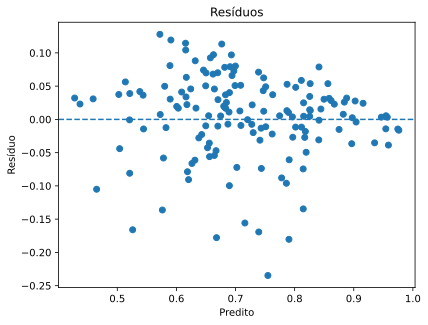

In [71]:
# calcular o residuo
y_pred = best_model.predict(X_test)
residuos = y_test - y_pred

# exbir o gráfico
plt.scatter(y_pred, residuos)
plt.axhline(0, linestyle='--')
plt.xlabel('Predito')
plt.ylabel('Resíduo')
plt.title("Resíduos")
plt.show()

### 9. Carrega database de Biomassa e pré-processa

In [72]:
scaler = MinMaxScaler()

df = load_df(DF_BIOMASSA)

y = df['biomassa']
X = df.drop('biomassa', axis = 1)

# Separa em treino, teste e indices
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=TEST_SIZE,
    random_state=RAND_SEED
)

# Preprocessa features
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

### 10. Treina em diferentes modelos e armazena os resultados

In [73]:
resultado_biomassa = treina_avalia(models, X_train, X_test, y_train, y_test)

Melhores parametros para o modelo KNeighborsRegressor
{'n_neighbors': 3} 

Melhores parametros para o modelo MLPRegressor
{'hidden_layer_sizes': (100,), 'learning_rate_init': 0.1} 

Melhores parametros para o modelo SVR
{'C': 100, 'gamma': 'scale'} 

Melhores parametros para o modelo RandomForestRegressor
{'max_depth': 11, 'n_estimators': 80} 



In [74]:
# Experimento com base de Biomassa
print(' ')
print('###################')
print('Experimento - Biomassa')
display(resultado_biomassa)

 
###################
Experimento - Biomassa


,R2,Parametros,Syx,Pearson,RMSE,MAE
Tecnica,,,,,,
RNA_CV,0.8,"{'hidden_layer_sizes': (100,), 'learning_rate_init': 0.1}",986.57,0.97,993.98,211.53
RF_CV,0.62,"{'max_depth': 11, 'n_estimators': 80}",1362.83,0.94,1368.97,249.01
RF_DEFAULT,0.61,Valores default,1385.37,0.93,1391.74,251.15
KNN,0.51,{'n_neighbors': 3},1547.44,0.9,1557.77,289.75
SVM_CV,0.07,"{'C': 100, 'gamma': 'scale'}",2119.69,0.52,2138.51,389.21
SVM_HOLD_OUT,-0.04,Valores default,2225.38,0.71,2255.72,483.29
RNA_HOLD_OUT,-0.05,Valores default,2223.74,0.77,2266.11,497.97


### 11. Faz predição para dados novos de Biomassa usando o melhor modelo

In [75]:
# obtem o melhor modelo
best_model_name = resultado_biomassa.index[0]
best_model = models[best_model_name]

# carrega novos dados
X_novo = load_df(DADOS_NOVOS_BIOMASSA)

# Preprocessa features
X_novo = scaler.transform(X_novo)

# faz a predição
y_novo = np.round(best_model.predict(X_novo),2)
print(y_novo.tolist())


[13.39, 33.19, 11.37, 36.61]


### 12. Gráfico dos resíduos da melhor predição

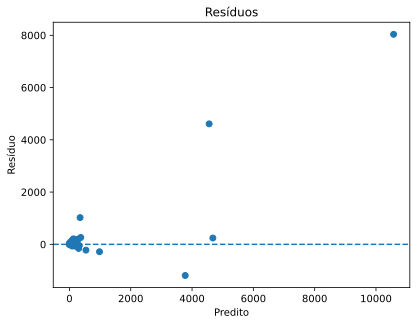

In [76]:
# calcular o residuo
y_pred = best_model.predict(X_test)
residuos = y_test - y_pred

# exbir o gráfico
plt.scatter(y_pred, residuos)
plt.axhline(0, linestyle='--')
plt.xlabel('Predito')
plt.ylabel('Resíduo')
plt.title("Resíduos")
plt.show()